In [1]:
import gc
import argparse

import matplotlib.pyplot as plt
import numpy as np

from datatree import open_datatree
from scipy.stats import describe

from var_assim.plotting.presets import get_presets
from var_assim.plotting.bias_perc_error_over_time import make_grid_plot, test_make_grid_plot
from var_assim.plotting.filtering import filter_by_max_conceivable, filter_datatree_by_cost_ratio_memeff
from var_assim.plotting.pproc import get_angle_r2
from var_assim.config import PRIOR_PATH, NOISE_PATH, TRUTH_PATH, WINDOW_PATH, DATA_DIR, DATA_DIR_ABS
from var_assim.calibration.priors import ClimateModelPriors
from var_assim.calibration.noise import ClimateModelNoise
from var_assim.calibration.truth import ClimateModelTruth
from var_assim.calibration.windowing import AssimilationWindowing

presets, _ = get_presets()
plt.rcParams.update(presets)

In [2]:
# test_make_grid_plot()

In [3]:
presets, basefile = get_presets()
plt.rcParams.update(presets)
SAVE_FIGS = True

Models by grid:
- Row 1: AR(1), ssp2, 0.1 deg / dec
- Row 2: ar(1), ssp5, 0.1 deg / dec
- Row 3: AR(1), ssp2, 0.2 deg / dec
- Row 4: No noise, sps2, 0.1 deg / dec

In [4]:
# properties that change across models
panel_configs = {
    'pco2geowc_ssp245_ar1': {
        'prefix': 'margobs_ws',
        'ssp': 'ssp245',
        'model': 'pco2geowc',
        'noise_model': 'AR1',
        'degpdec': 0.1
    },

    'pco2geowc_ssp585_ar1': {
        'prefix': 'margobs_ws',
        'ssp': 'ssp585',
        'model': 'pco2geowc',
        'noise_model': 'AR1',
        'degpdec': 0.1
    },

    'pco2geowc_ssp245_ar1_repeat': {
        'prefix': 'margobs_ws',
        'ssp': 'ssp245',
        'model': 'pco2geowc',
        'noise_model': 'AR1',
        'degpdec': 0.2
    },

    'pco2geowc_nn_ssp245': {
        'prefix': 'margobs_ws_nonoise',
        'ssp': 'ssp245',
        'model': 'pco2geowc_nn',
        'noise_model': 'nn',
        'degpdec': 0.1
    },
}

# properties that are constant across models
angles_file = ['9', '12', '14', '17', '21', '33']
reg_noise = False
ECS = 3.0
NYRSRAMP = 50
Nwinds = '14custom'
Nwinds_number = 14
windowing_config = 'original'
Nens = 500
TMIN = 2025
ANGLE_MAX_CONCEIVABLE = 45. 

In [5]:
# empty lists for filling later
angles = np.zeros((len(panel_configs), len(angles_file), Nwinds_number, Nens))
angles_tr = np.zeros(len(angles_file))
angles_prior = np.zeros(Nens)

In [6]:
for idx, config in enumerate(panel_configs.keys()):
    # store config as local variables
    prefix = panel_configs[config]['prefix']
    ssp = panel_configs[config]['ssp']
    model = panel_configs[config]['model']
    noise_model = panel_configs[config]['noise_model']
    DEGpDEC = panel_configs[config]['degpdec']

    for angx, th in enumerate(angles_file):
        # make temporary CLI namespace for processing
        cli_args = argparse.Namespace(
            model=model,
            ssp=ssp,
            noise_model=noise_model,
            tmin=TMIN,
            theta=float(th),
            AR=1 if model != 'pco2geowc_nn' else None,
            ecs=ECS,
            DEGpDEC=DEGpDEC,
            NYRSRAMP=NYRSRAMP,
            Nwinds=Nwinds,
            Nens=Nens,
            reg_noise=reg_noise,
            windowing=windowing_config
        )

        # setup data classes
        Noise = ClimateModelNoise.from_cli_and_yaml(cli_args, NOISE_PATH)
        Prior = ClimateModelPriors.from_cli_and_yaml_and_noise(cli_args, PRIOR_PATH, Noise)
        Windowing = AssimilationWindowing.from_cli_and_yaml(cli_args, WINDOW_PATH)
        Truth = ClimateModelTruth.from_cli_and_yaml(cli_args, TRUTH_PATH)

        # compute true value of angle
        if idx == 0:
            angles_tr[angx] = get_angle_r2(
                Truth.ALPHA_TR[0], Truth.ALPHA_TR[1],
                Truth.BETA_TR[0], Truth.BETA_TR[1],
                Truth.L_TR, Truth.EPS_TR, Truth.G_TR
                )
            if idx == 1:
                print(f"True values of the theta parameter are: {angles_tr}")

        # import data
        if model == 'pco2geowc_nn':
            fname = DATA_DIR_ABS / "output" / model / (
                    f"{prefix}_{ssp}_{model}_TMIN{TMIN}_THETA{th}_ECS{ECS}_DEGpDEC{DEGpDEC}_NYRSRAMP{NYRSRAMP}_Nwinds{Nwinds}_Nens{Nens}.nc"
                )

        else:
            fname = DATA_DIR_ABS / "output" / model / (
                    f"{prefix}_{ssp}_{model}_TMIN{TMIN}_{noise_model}_THETA{th}_ECS{ECS}_DEGpDEC{DEGpDEC}_NYRSRAMP{NYRSRAMP}_Nwinds{Nwinds}_Nens{Nens}.nc"
                )

        ## variables we need for analysis (only do for first run through, constant across configs)
        if idx == 0 and angx == 0:
            dt_meta = open_datatree(fname, engine='netcdf4')
            relevant_vars = ['cost_hist', 'controls', 'controls_hist']
            dropped_vars = [v for v in dt_meta['2027'].ds.data_vars if v not in relevant_vars]
            # dt_meta.close()

        # open and clean dataset
        dt = open_datatree(fname, engine='netcdf4', drop_variables=dropped_vars)
        dt_clean = filter_datatree_by_cost_ratio_memeff(dt, threshold=1e-2, clear_after_each_node=True)

        # make priors (only have to do once)
        if idx == 0 and angx == 0:
            prior_a1 = dt['2027'].ds.controls_hist.sel(vari='ALPHA_R1', iter=0).values
            prior_b1 = dt['2027'].ds.controls_hist.sel(vari='BETA_R1', iter=0).values
            prior_a2 = dt['2027'].ds.controls_hist.sel(vari='ALPHA_R2', iter=0).values
            prior_b2 = dt['2027'].ds.controls_hist.sel(vari='BETA_R2', iter=0).values
            prior_l = dt['2027'].ds.controls_hist.sel(vari='L', iter=0).values
            prior_g = dt['2027'].ds.controls_hist.sel(vari='G', iter=0).values
            prior_eps = dt['2027'].ds.controls_hist.sel(vari='EPS', iter=0).values

            for i in range(Nens):
                angles_prior[i] = get_angle_r2(prior_a1[i], prior_a2[i],
                                               prior_b1[i], prior_b2[i],
                                               prior_l[i], prior_eps[i], prior_g[i])
            
            print("Angle prior summary statistics:")
            for key, value in describe(angles_prior)._asdict().items():
                print(f"{key:>10}: {value}")

        # compute angles
        winds = np.array([w[1] for w in Windowing.windows])
        windss = [str(w) for w in winds]

        for w_, w in enumerate(windss):
            tmp_a1 = dt[w].ds.controls.sel(vari='ALPHA_R1').values
            tmp_a2 = dt[w].ds.controls.sel(vari='ALPHA_R2').values
            tmp_b1 = dt[w].ds.controls.sel(vari='BETA_R1').values
            tmp_b2 = dt[w].ds.controls.sel(vari='BETA_R2').values
            tmp_l = dt[w].ds.controls.sel(vari='L').values
            tmp_g = dt[w].ds.controls.sel(vari='G').values
            tmp_eps = dt[w].ds.controls.sel(vari='EPS').values
            for i in range(Nens):
                angles[idx, angx, w_, i] = get_angle_r2(tmp_a1[i], tmp_a2[i],
                                                        tmp_b1[i], tmp_b2[i], 
                                                        tmp_l[i], tmp_eps[i], tmp_g[i])
                
        # cleanup
        for node in dt.subtree:
            if node.ds is not None:
                node.ds.close()

        del dt
        gc.collect()
                
angles_filtered = filter_by_max_conceivable(angles, ANGLE_MAX_CONCEIVABLE)


Found 15 nodes in tree
Processing node 1: /2027
  Memory: 7.4 MB
  Result: 500 kept, 0 filtered
Processing node 2: /2029
  Memory: 8.2 MB
  Result: 494 kept, 6 filtered
Processing node 3: /2031
  Memory: 9.0 MB
  Result: 499 kept, 1 filtered
Processing node 4: /2033
  Memory: 9.7 MB
  Result: 496 kept, 4 filtered
Processing node 5: /2035
  Memory: 10.5 MB
  Result: 498 kept, 2 filtered
Processing node 6: /2037
  Memory: 11.3 MB
  Result: 487 kept, 13 filtered
Processing node 7: /2039
  Memory: 12.1 MB
  Result: 491 kept, 9 filtered
Processing node 8: /2041
  Memory: 12.8 MB
  Result: 493 kept, 7 filtered
Processing node 9: /2043
  Memory: 13.6 MB
  Result: 493 kept, 7 filtered
Processing node 10: /2045
  Memory: 14.4 MB
  Result: 489 kept, 11 filtered
Processing node 11: /2047
  Memory: 15.2 MB
  Result: 487 kept, 13 filtered
Processing node 12: /2049
  Memory: 16.0 MB
  Result: 493 kept, 7 filtered
Processing node 13: /2075
  Memory: 26.1 MB
  Result: 491 kept, 9 filtered
Processing n

In [7]:
row_titles = [
    r'SSP2-4.5 | $\Delta$ T / decade = 0.1 $^\circ$C / decade | AR(1) Internal Variability',
    r'SSP5-8.5 | $\Delta$ T / decade = 0.1 $^\circ$C / decade | AR(1) Internal Variability',
    r'SSP2-4.5 | $\Delta$ T / decade = 0.2 $^\circ$C / decade | AR(1) Internal Variability',
    r'SSP2-4.5 | $\Delta$ T / decade = 0.1 $^\circ$C / decade | No Internal Variability',
]

Figure saved to: /project/bbcael/ambauer/learning_sai/analysis/figs/results/2026-05-20-grid-bias-error-TMIN2025-Nwinds14custom-Nens500.png


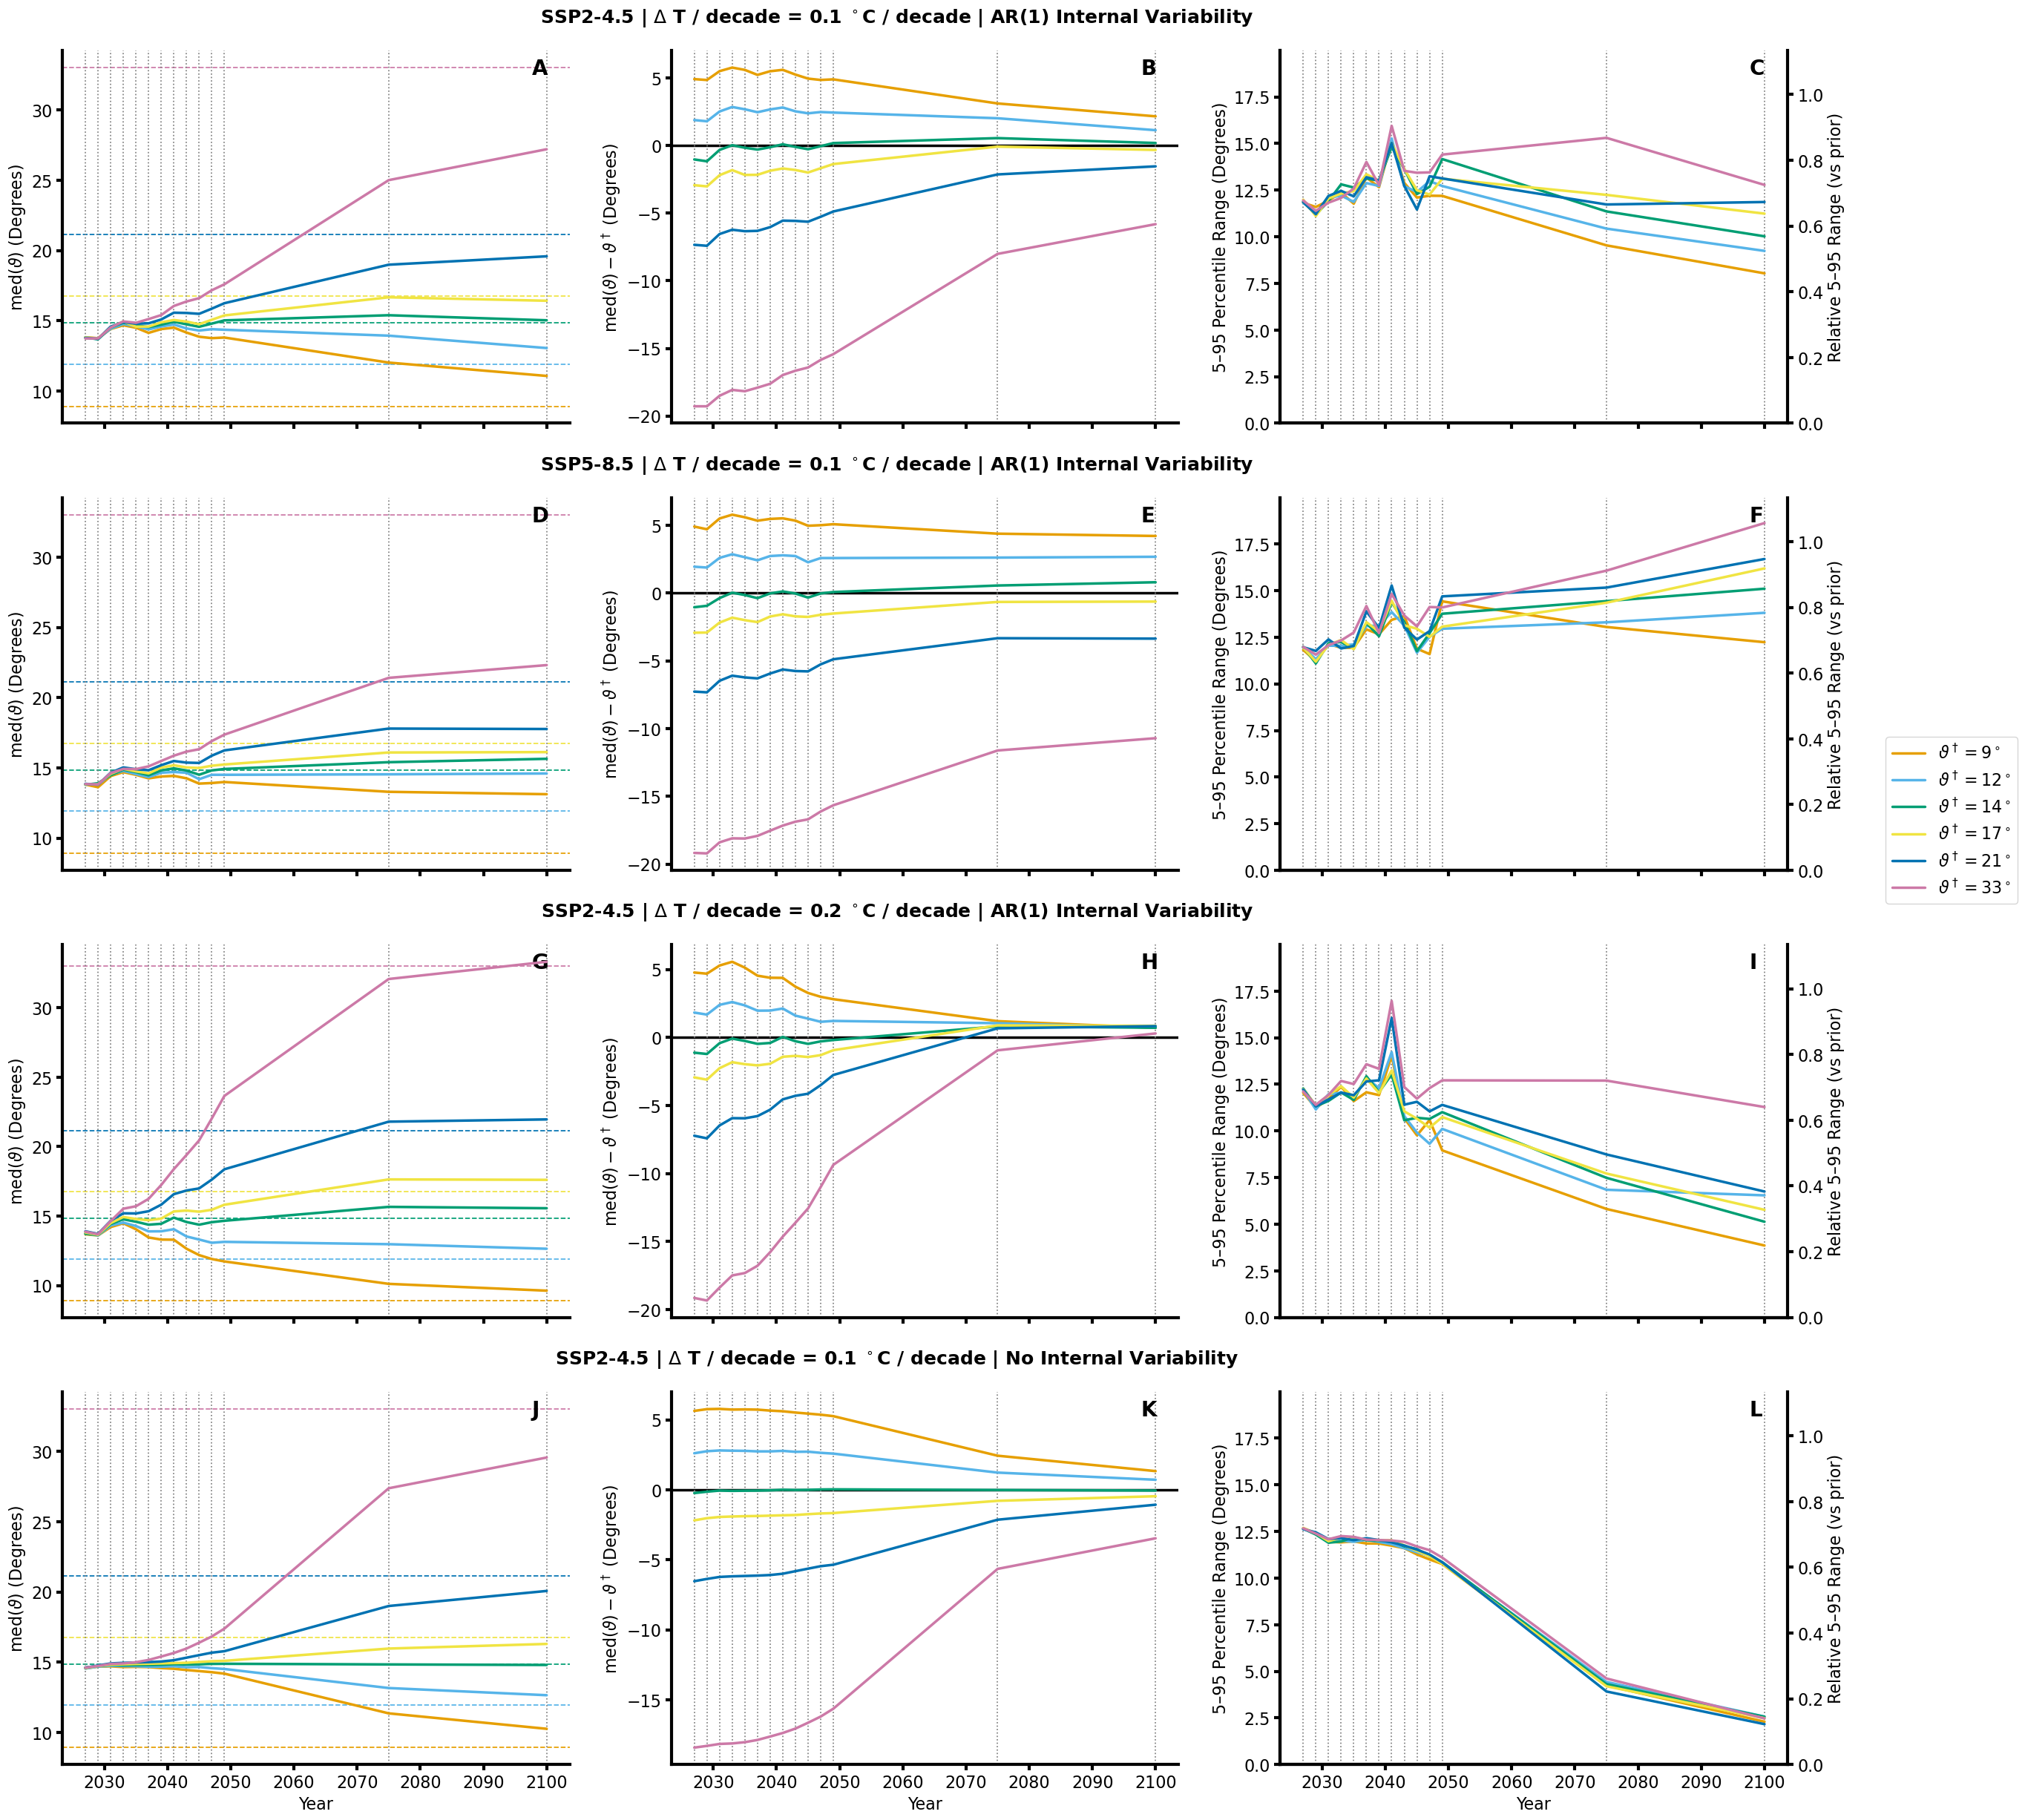

In [8]:
_, _, make_grid_plot(angles, angles_tr, angles_prior, angles_file,
                     winds, PLO=5, PHI=95,
                     row_titles=row_titles,
                     save_figs=SAVE_FIGS,
                     fname=f'grid-bias-error-TMIN{TMIN}-Nwinds{Nwinds}-Nens{Nens}')

plt.show()

Figure saved to /project/bbcael/ambauer/learning_sai/analysis/notebooks/figs/2026-5-15-ens-med-bias-percrange-margobs_ws-ssp245-TMIN2025-AR1-ECS3.0-DEGpDEC0.1-Nwinds14custom-Nens500.png


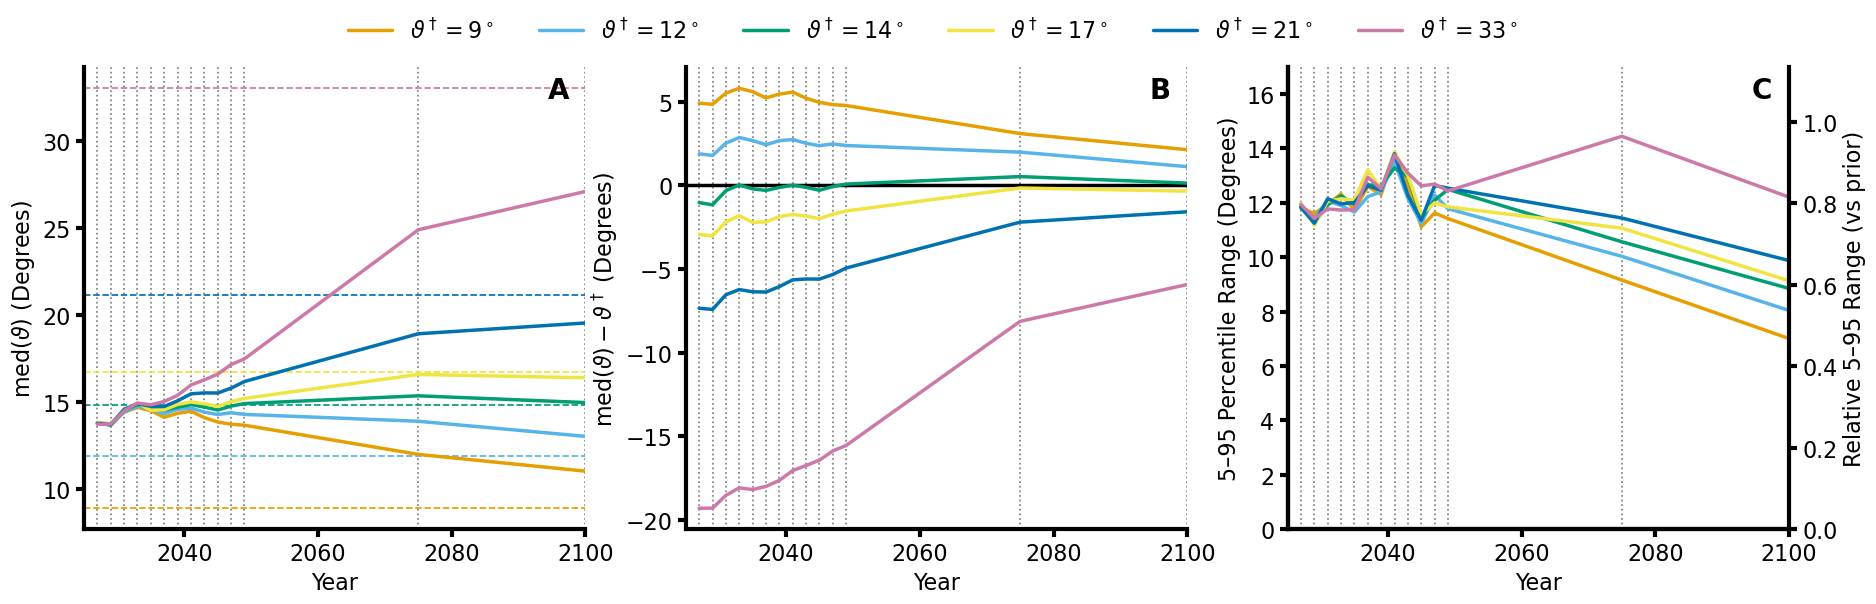

In [ ]:
fig, ax = plt.subplots(1, 3, figsize=(22, 6))

YMIN, YMAX = 5, 25
PLO, PHI = 5, 95

for a in ax:
    a.set_xlim((2025, 2100))

for w in winds:
    for a in ax:
        a.axvline(w, linestyle='dotted', color='grey', linewidth=1.25)
        a.set_xlabel("Year")

for i in range(len(angles_file)):
    ax[0].plot(winds, np.nanmedian(angles_filtered[i], axis=1),
               linestyle='solid', color=color_list[i+1],
               label=r'$\vartheta^\dagger=${}$^\circ$'.format(angles_file[i]), zorder=100)

    ax[0].axhline(angles_tr[i], linestyle='dashed', linewidth=1.25, color=color_list[i+1])

    ax[1].plot(winds, np.nanmedian(angles_filtered[i], axis=1) - angles_tr[i], 
           color=color_list[i+1], zorder=100, linestyle='solid')

    ax[2].plot(winds, np.nanpercentile(angles_filtered[i], PHI, axis=1) - np.nanpercentile(angles_filtered[i], PLO, axis=1), 
           label=r'$\vartheta*=${}$^\circ$'.format(angles_file[0]), zorder=100, color=color_list[i+1], linestyle='solid')

ax[0].set_ylabel(r"med$(\vartheta)$ (Degrees)")
ax[0].legend(bbox_to_anchor=(2.9, 1.15), ncols=len(angles_file))

ax[1].set_ylabel(r"med$(\vartheta) - \vartheta^\dagger$ (Degrees)")
ax[1].axhline(0, color='k', linestyle='solid')

ax[2].set_ylabel(f"{PLO}–{PHI} Percentile Range (Degrees)")
ax[2].set_ylim((0, 2 + np.nanpercentile(angles_prior, PHI) - np.nanpercentile(angles_prior, PLO)))

ax2_rel = ax[2].twinx()
ax2_rel.set_ylabel(f"Relative {PLO}–{PHI} Range (vs prior)")
ax2_rel.spines['right'].set_visible(True)
ax2_rel.set_ylim((0, (2 + np.nanpercentile(angles_prior, PHI) - np.nanpercentile(angles_prior, PLO)) / (np.nanpercentile(angles_prior, PHI) - np.nanpercentile(angles_prior, PLO))))

# Add bold, all-caps panel labels
for a, label in zip(ax, ['A', 'B', 'C']):
    a.text(0.925, 0.98, label, transform=a.transAxes,
           fontsize=20, fontweight='bold', va='top', ha='left')

if SAVE_FIGS:
    filename = "ens-med-bias-percrange-{}-{}-TMIN{}-AR{}-ECS{}-DEGpDEC{}-Nwinds{}-Nens{}.png".format(prefix, ssp, TMIN, AR, ECS, DEGpDEC, Nwinds, Nens)
    # fig.savefig(basefile + filename, dpi=350, bbox_inches='tight')
    print("Figure saved to {}".format(basefile + filename))

plt.show()

In [ ]:
import seaborn as sb
import pandas as pd

In [ ]:
np.hstack([np.arange(2027, 2050, 2), [2075, 2100]])[-2]

In [ ]:
# prepare data for plotting
tr_, yr_ = 2, '2049'  # choose true value index and assimilation year ('obs up to X')
ds = dts[tr_][yr_].ds

angles_sel = angles[tr_, -3]

data = np.zeros((13, Nens))
data[0] = np.where(angles_sel > np.percentile(angles_prior, 95), np.nan, ds.controls.sel(vari='L').values)
data[1] = np.where(angles_sel > np.percentile(angles_prior, 95), np.nan, ds.controls.sel(vari='G').values)
data[2] = np.where(angles_sel > np.percentile(angles_prior, 95), np.nan, ds.controls.sel(vari='EPS').values)
data[3] = np.where(angles_sel > np.percentile(angles_prior, 95), np.nan, ds.controls.sel(vari='C1').values)
data[4] = np.where(angles_sel > np.percentile(angles_prior, 95), np.nan, ds.controls.sel(vari='C2').values)
data[5] = np.where(angles_sel > np.percentile(angles_prior, 95), np.nan, ds.controls.sel(vari='F1_CO2').values)
data[6] = np.where(angles_sel > np.percentile(angles_prior, 95), np.nan, ds.controls.sel(vari='ALPHA_R1').values)
data[7] = np.where(angles_sel > np.percentile(angles_prior, 95), np.nan, ds.controls.sel(vari='ALPHA_R2').values)
data[8] = np.where(angles_sel > np.percentile(angles_prior, 95), np.nan, ds.controls.sel(vari='BETA_R1').values/0.09)
data[9] = np.where(angles_sel > np.percentile(angles_prior, 95), np.nan, ds.controls.sel(vari='BETA_R2').values/0.09)
data[10] = np.where(angles_sel > np.percentile(angles_prior, 95), np.nan, angles_sel)
data[11] = np.where(angles_sel > np.percentile(angles_prior, 95), np.nan, data[5] / data[0])
data[12] = np.where(angles_sel > np.percentile(angles_prior, 95), np.nan, data[5] / (data[0] + data[1] * data[2]))

In [ ]:
df_all = pd.DataFrame(data=data.T,
    columns=[r'$\lambda$ (K / W m$^{-2}$)', r'$\gamma$ (K / W m$^{-2}$)', r'$\varepsilon$ ($-$)', r'$C_1$', r'$C_2$',
             r'$f^{(CO_2)}_1$ (W m$^{-2})$', r'$\alpha_{R1}$ ($-$)', r'$\alpha_{R2}$ ($-$)',
             r'$\beta_{R1}$ (K / W m$^{-2}$)', r'$\beta_{R2}$ (K / W m$^{-2}$)', r'$\vartheta$ (Degrees)', 'ECS (K)', 'TCR (K)']
)

In [ ]:
df_all

In [ ]:
from scipy import stats
# Assuming your dataframe is called 'df'
theta_col = r'$\vartheta$ (Degrees)'

# Get the independent variable (theta)
theta = df_all[theta_col]

results = {}
r_tot = 0

# Loop through each column
for col in df_all.columns:
    # Skip the theta column itself
    if col == theta_col or col == 'ECS (K)' or col == 'TCR (K)':
        continue
    
    # Get the dependent variable
    y = df_all[col]
    
    # Remove NaN values
    mask = ~(np.isnan(theta) | np.isnan(y))
    theta_clean = theta[mask]
    y_clean = y[mask]
    
    # Perform linear regression
    slope, intercept, r_value, p_value, std_err = stats.linregress(
        theta[mask], y[mask]
    )

    r_tot += r_value**2
    
    results[col] = {
        'slope': slope,
        'intercept': intercept,
        'r_squared': r_value**2,
        'p_value': p_value,
        'std_err': std_err
    }

# Convert to DataFrame and sort by R² (descending)
results_df = pd.DataFrame(results).T
results_df = results_df.sort_values('r_squared', ascending=False)

print(results_df)
print(f"\n\nVariables ranked by variance explained (R²):")
print("="*60)
for i, (var, row) in enumerate(results_df.iterrows(), 1):
    print(f"{i}. {var}")
    print(f"   R² = {row['r_squared']/r_tot:.4f} ({row['r_squared']*100/r_tot:.2f}% variance explained)")
    print(f"   Slope = {row['slope']:.4f}, p-value = {row['p_value']:.4e}\n")

In [ ]:
pp = sb.pairplot(df_all,
                diag_kind='kde', corner=True, dropna=True)

In [ ]:

pp = sb.pairplot(df_all, vars=[r'$\lambda$ (K / W m$^{-2}$)', r'$\gamma$ (K / W m$^{-2}$)',
                               r'$f^{(CO_2)}_1$ (W m$^{-2})$', r'$\beta_{R1}$ (K / W m$^{-2}$)', 
                               r'$\beta_{R2}$ (K / W m$^{-2}$)', r'$\vartheta$ (Degrees)'],
                 diag_kind='kde', corner=True, dropna=True)

prior_f = np.random.normal(4.58, 0.519, size=500)
prior_samples = [prior_l, prior_g, prior_f, prior_b1/0.09, prior_b2/0.09, angles_prior]
var_truth = [L_CEN, G_CEN, 4.58, 0.018/0.09, -0.018/0.09, angles_tr[tr_]]

# add priors on the diagonals
for i, ax in enumerate(pp.diag_axes):
    x = np.linspace(min(prior_samples[i]), max(prior_samples[i]), 200)
    zeros = np.zeros_like(x)
    
    kde = stats.gaussian_kde(prior_samples[i])

    ax2 = ax.twinx()
    ax2.plot(x, kde(x), 'r-', label='Prior', zorder=-1)
    ax2.axvline(var_truth[i], linestyle='dashed', color='b', label="True value")
    ax2.set_xlim((ax.get_xlim()[0], ax.get_xlim()[1]))
    
    #ax2.fill_between(x, zeros, kde(x), alpha=0.3, color='r', zorder=-1)
    
    ax2.set_ylabel('')
    ax2.set_yticks([])

    if i == 0:
        ax2.plot([2.0], [0], 'k-', label="Posterior")
        ax2.legend(bbox_to_anchor=(2.0, 1.0))

if SAVE_FIGS:
    filename = 'corner-regional.svg'
    # pp.savefig(basefile + filename)

In [ ]:
results_df